<a href="https://colab.research.google.com/github/juanorozco203/CHALLENGE-ALURA-STORE-LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import pandas as pd
import json
import requests



Importar datos desde la API

In [4]:


url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

response = requests.get(url)
data = response.json()

# Convertir a DataFrame
df = pd.DataFrame(data)

# Verificar que se cargaron bien
print(" Carga correcta de los datos!")
print(f" Filas: {df.shape[0]}")
print(f" Columnas: {df.shape[1]}")
print("\n Primeras filas:")
df.head()

 Carga correcta de los datos!
 Filas: 7267
 Columnas: 6

 Primeras filas:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

## **Estructura general del DataSet**
### En esta ejecucion de codigo veremos el total de filas y columnas del dataset


In [5]:
# 1. Estructura general
print("=" * 50)
print("📋 ESTRUCTURA DEL DATASET")
print("=" * 50)
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

📋 ESTRUCTURA DEL DATASET
Filas: 7267
Columnas: 6


Tipos de datos por columna

In [7]:
print("\n" + "=" * 50)
print("🔍 TIPOS DE DATOS")
print("=" * 50)
print(df.dtypes)



🔍 TIPOS DE DATOS
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


Primeras 5 filas

In [8]:
print("\n" + "=" * 50)
print("👀 PRIMERAS 5 FILAS")
print("=" * 50)
df.head()


👀 PRIMERAS 5 FILAS


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Informacion general (fundamental para entender la estructura del dataset)

In [9]:
print("=" * 50)
print("ℹ️ INFORMACIÓN GENERAL")
print("=" * 50)
df.info()

ℹ️ INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Columnas mas relevantes

In [11]:
print("=" * 50)
print("🎯 COLUMNAS RELEVANTES PARA CHURN")
print("=" * 50)
print("""
Variables clave a analizar:
- Churn          → Variable objetivo (cliente se fue o no)
- tenure         → Tiempo como cliente (meses)
- Contract       → Tipo de contrato
- MonthlyCharges → Cargo mensual
- TotalCharges   → Cargo total
- PaymentMethod  → Método de pago
- InternetService→ Tipo de servicio de internet
- TechSupport    → Soporte técnico
- OnlineSecurity → Seguridad en línea
""")

🎯 COLUMNAS RELEVANTES PARA CHURN

Variables clave a analizar:
- Churn          → Variable objetivo (cliente se fue o no)
- tenure         → Tiempo como cliente (meses)
- Contract       → Tipo de contrato
- MonthlyCharges → Cargo mensual
- TotalCharges   → Cargo total
- PaymentMethod  → Método de pago
- InternetService→ Tipo de servicio de internet
- TechSupport    → Soporte técnico
- OnlineSecurity → Seguridad en línea



### Verificacion de duplicados:
En este paso verificaremos las colimnas que tienen diccionarios (llamados tambien datos anidados) adentro para asi aplanar el data set antes de continuar.
Estos diccionarios son muy comunes en archivos json como lo es este.


In [16]:

print("Columnas con datos anidados:")
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, dict)).any():
        print(f"   {col}")

Columnas con datos anidados:
   customer
   phone
   internet
   account


Una vez identificadas las columnas con estos diccionarios continiamos con la aplanacion de las mismas

In [17]:
df_customer  = pd.json_normalize(df['customer'])
df_phone     = pd.json_normalize(df['phone'])
df_internet  = pd.json_normalize(df['internet'])
df_account   = pd.json_normalize(df['account'])

Procedemos a ver qué columnas salieron de cada una

In [18]:
print("📌 customer:", df_customer.columns.tolist())
print("📌 phone:",    df_phone.columns.tolist())
print("📌 internet:", df_internet.columns.tolist())
print("📌 account:",  df_account.columns.tolist())

📌 customer: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']
📌 phone: ['PhoneService', 'MultipleLines']
📌 internet: ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
📌 account: ['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


Ya con las columnas identid¿ficadas procedemos a unir todo en un dataframe limpio

In [21]:
df_flat = pd.concat([
    df.drop(columns=['customer', 'phone', 'internet', 'account']),
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

print(f" DataFrame aplanado!")
print(f" Filas: {df_flat.shape[0]}")
print(f" Columnas: {df_flat.shape[1]}")
print("\nColumnas finales:")
print(df_flat.columns.tolist())

 DataFrame aplanado!
 Filas: 7267
 Columnas: 21

Columnas finales:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


Ahora verificamos los duplicados sin error(debe aparecer 0) y asi darnos cuenta de que el dataset esta limpio.

In [22]:
duplicados = df_flat.duplicated().sum()
print(f"🔁 Filas duplicadas: {duplicados}")

🔁 Filas duplicadas: 0


###Crearemos la columna **"Cuentas Diarias**".
Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.


Primero verificamos cómo se llama la columna de facturación mensual

In [23]:
print("Columnas disponibles relacionadas con cargos:")
print([col for col in df_flat.columns if 'charge' in col.lower() or 'cargo' in col.lower()])

Columnas disponibles relacionadas con cargos:
['Charges.Monthly', 'Charges.Total']


Creamos las columnas cuentas diarias

In [25]:
df_flat['Cuentas_Diarias'] = df_flat['Charges.Monthly'] / 30

print(" Columna 'Cuentas_Diarias' creada!")
print("\n Primeros valores:")
df_flat[['Charges.Monthly', 'Cuentas_Diarias']].head(10)

 Columna 'Cuentas_Diarias' creada!

 Primeros valores:


,Charges.Monthly,Cuentas_Diarias
0,65.60,2.186667
1,59.90,1.996667
2,73.90,2.463333
3,98.00,3.266667
4,83.90,2.796667
5,69.40,2.313333
6,109.70,3.656667
7,84.65,2.821667
8,48.20,1.606667
9,90.45,3.015000


Estadísticas de la nueva columna

In [26]:
print("📈 Estadísticas de Cuentas_Diarias:")
print(df_flat['Cuentas_Diarias'].describe().round(2))

📈 Estadísticas de Cuentas_Diarias:
count    7267.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         3.00
max         3.96
Name: Cuentas_Diarias, dtype: float64


#📊 Carga y análisis

## Analisis descriptivo

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns



Configuracion de graficos

In [35]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
COLORES = ['#2E6DA4', '#E8A838']

Estadisticas generales de todas las columnas numericas

In [36]:
print("=" * 50)
print("ESTADÍSTICAS GENERALES")
print("=" * 50)
df_flat.describe().round(2)

ESTADÍSTICAS GENERALES


,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7267.00,7267.00,7267.00,7267.00
mean,0.16,32.35,64.72,2.16
std,0.37,24.57,30.13,1.00
min,0.00,0.00,18.25,0.61
25%,0.00,9.00,35.42,1.18
50%,0.00,29.00,70.30,2.34
75%,0.00,55.00,89.88,3.00
max,1.00,72.00,118.75,3.96


Métricas detalladas por columna numérica

In [37]:
import numpy as np

cols_numericas = df_flat.select_dtypes(include=['int64', 'float64']).columns

resumen = pd.DataFrame({
    'Media'          : df_flat[cols_numericas].mean(),
    'Mediana'        : df_flat[cols_numericas].median(),
    'Desv. Estándar' : df_flat[cols_numericas].std(),
    'Mínimo'         : df_flat[cols_numericas].min(),
    'Máximo'         : df_flat[cols_numericas].max(),
    'Asimetría'      : df_flat[cols_numericas].skew(),
    'Curtosis'       : df_flat[cols_numericas].kurt()
}).round(2)

print(" MÉTRICAS DETALLADAS:")
resumen

 MÉTRICAS DETALLADAS:


,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Asimetría,Curtosis
SeniorCitizen,0.16,0.00,0.37,0.00,1.00,1.83,1.34
tenure,32.35,29.00,24.57,0.00,72.00,0.24,-1.39
Charges.Monthly,64.72,70.30,30.13,18.25,118.75,-0.22,-1.26
Cuentas_Diarias,2.16,2.34,1.00,0.61,3.96,-0.22,-1.26


Tasa de evacion general

Total clientes:     7267
Clientes evadidos:  1869  (25.72%)
Clientes retenidos: 5174  (74.28%)


/tmp/ipykernel_2344/1469364436.py:41: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


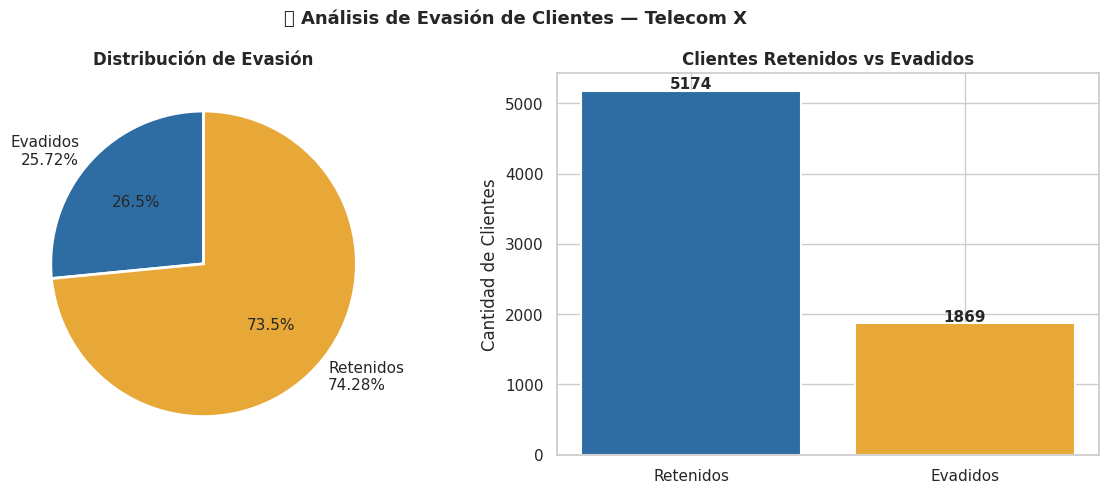

In [39]:
total        = len(df_flat)
evadidos     = (df_flat['Churn'] == 'Yes').sum()
no_evadidos  = (df_flat['Churn'] == 'No').sum()
tasa_evasion = (evadidos / total * 100).round(2)

print(f"Total clientes:     {total}")
print(f"Clientes evadidos:  {evadidos}  ({tasa_evasion}%)")
print(f"Clientes retenidos: {no_evadidos}  ({100 - tasa_evasion}%)")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    [evadidos, no_evadidos],
    labels=[f'Evadidos\n{tasa_evasion}%', f'Retenidos\n{100-tasa_evasion}%'],
    colors=COLORES,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribución de Evasión', fontweight='bold')

# Bar chart
barras = axes[1].bar(
    ['Retenidos', 'Evadidos'],
    [no_evadidos, evadidos],
    color=COLORES, edgecolor='white', linewidth=1.5
)
axes[1].set_title('Clientes Retenidos vs Evadidos', fontweight='bold')
axes[1].set_ylabel('Cantidad de Clientes')
for barra in barras:
    axes[1].text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 30,
        f'{int(barra.get_height())}',
        ha='center', fontweight='bold'
    )

plt.suptitle('🚨 Análisis de Evasión de Clientes — Telecom X', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Evacion por tipo de contrato

         Contract  Total  Evadidos  Tasa_Evasion
0  Month-to-month   4005      1655         41.32
1        One year   1519       166         10.93
2        Two year   1743        48          2.75


/tmp/ipykernel_2344/3354898283.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contrato, x='Contract', y='Evadidos', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_2344/3354898283.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contrato, x='Contract', y='Tasa_Evasion', ax=axes[1], palette='Oranges_d')
/tmp/ipykernel_2344/3354898283.py:28: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


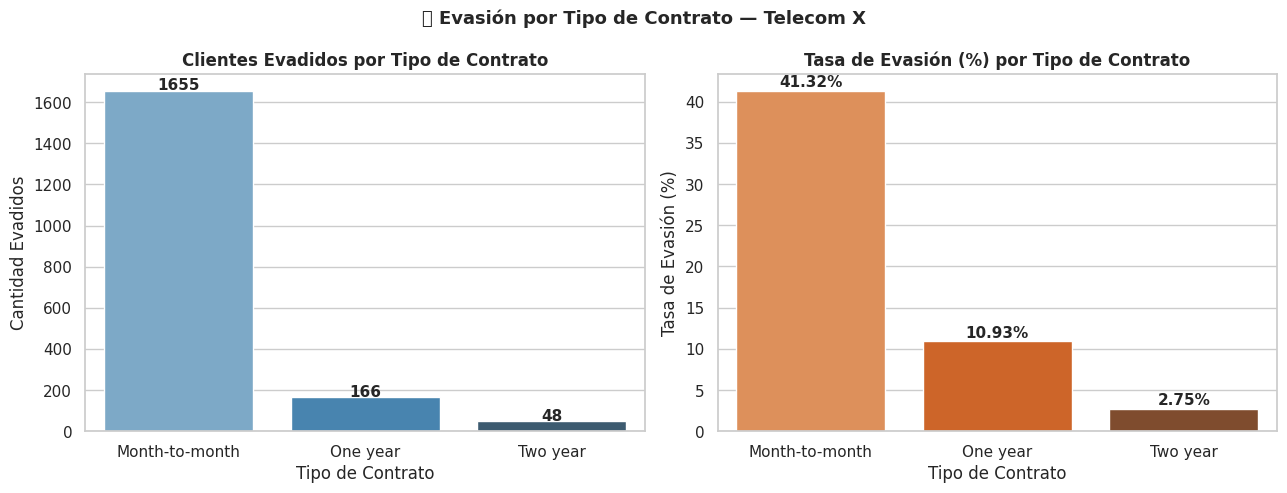

In [40]:
contrato = df_flat.groupby('Contract')['Churn'].agg(
    Total='count',
    Evadidos=lambda x: (x == 'Yes').sum(),
    Tasa_Evasion=lambda x: round((x == 'Yes').sum() / len(x) * 100, 2)
).reset_index()

print(contrato)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras cantidad
sns.barplot(data=contrato, x='Contract', y='Evadidos', ax=axes[0], palette='Blues_d')
axes[0].set_title('Clientes Evadidos por Tipo de Contrato', fontweight='bold')
axes[0].set_xlabel('Tipo de Contrato')
axes[0].set_ylabel('Cantidad Evadidos')
for i, row in contrato.iterrows():
    axes[0].text(i, row['Evadidos'] + 5, str(int(row['Evadidos'])), ha='center', fontweight='bold')

# Barras tasa %
sns.barplot(data=contrato, x='Contract', y='Tasa_Evasion', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Tasa de Evasión (%) por Tipo de Contrato', fontweight='bold')
axes[1].set_xlabel('Tipo de Contrato')
axes[1].set_ylabel('Tasa de Evasión (%)')
for i, row in contrato.iterrows():
    axes[1].text(i, row['Tasa_Evasion'] + 0.5, f"{row['Tasa_Evasion']}%", ha='center', fontweight='bold')

plt.suptitle('📋 Evasión por Tipo de Contrato — Telecom X', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Evasion por servicio de internet

  InternetService  Total  Evadidos  Tasa_Evasion
0             DSL   2488       459         18.45
1     Fiber optic   3198      1297         40.56
2              No   1581       113          7.15


/tmp/ipykernel_2344/3241596152.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet, x='InternetService', y='Evadidos', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_2344/3241596152.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet, x='InternetService', y='Tasa_Evasion', ax=axes[1], palette='Oranges_d')
/tmp/ipykernel_2344/3241596152.py:28: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


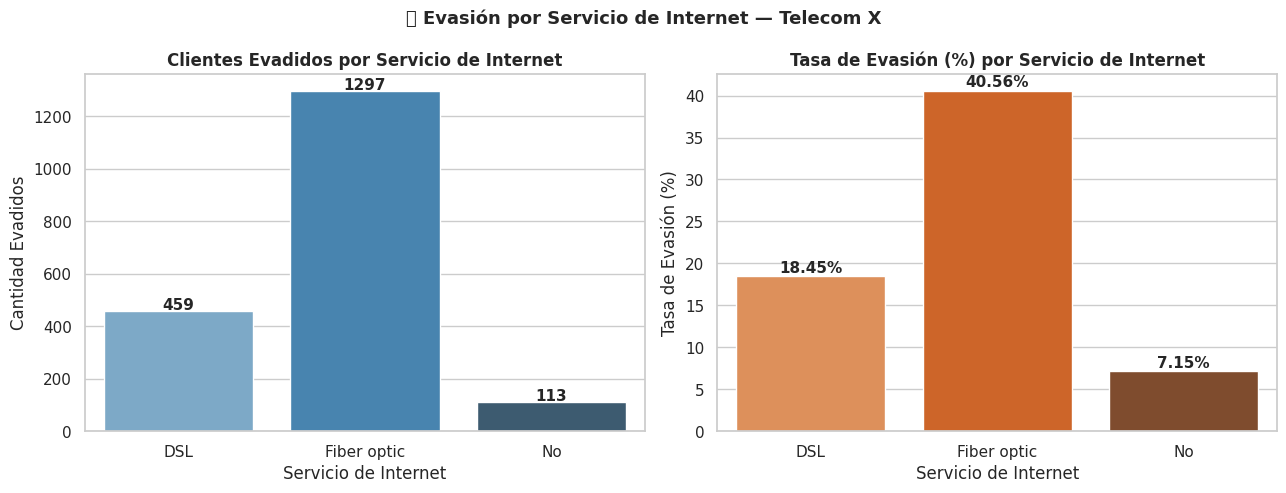

In [41]:
internet = df_flat.groupby('InternetService')['Churn'].agg(
    Total='count',
    Evadidos=lambda x: (x == 'Yes').sum(),
    Tasa_Evasion=lambda x: round((x == 'Yes').sum() / len(x) * 100, 2)
).reset_index()

print(internet)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras cantidad
sns.barplot(data=internet, x='InternetService', y='Evadidos', ax=axes[0], palette='Blues_d')
axes[0].set_title('Clientes Evadidos por Servicio de Internet', fontweight='bold')
axes[0].set_xlabel('Servicio de Internet')
axes[0].set_ylabel('Cantidad Evadidos')
for i, row in internet.iterrows():
    axes[0].text(i, row['Evadidos'] + 5, str(int(row['Evadidos'])), ha='center', fontweight='bold')

# Barras tasa %
sns.barplot(data=internet, x='InternetService', y='Tasa_Evasion', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Tasa de Evasión (%) por Servicio de Internet', fontweight='bold')
axes[1].set_xlabel('Servicio de Internet')
axes[1].set_ylabel('Tasa de Evasión (%)')
for i, row in internet.iterrows():
    axes[1].text(i, row['Tasa_Evasion'] + 0.5, f"{row['Tasa_Evasion']}%", ha='center', fontweight='bold')

plt.suptitle('🌐 Evasión por Servicio de Internet — Telecom X', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Distribucion demografica

/tmp/ipykernel_2344/1450735381.py:36: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


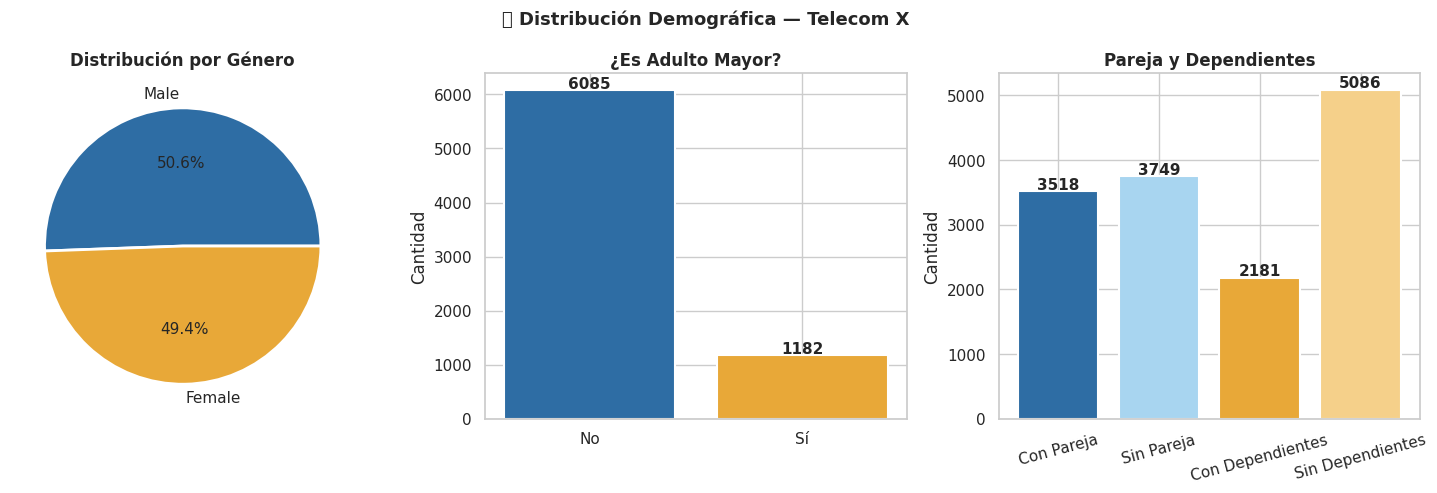

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Género
genero = df_flat['gender'].value_counts()
axes[0].pie(genero, labels=genero.index, autopct='%1.1f%%',
            colors=['#2E6DA4','#E8A838'], wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribución por Género', fontweight='bold')

# Adulto Mayor
adulto = df_flat['SeniorCitizen'].value_counts().rename({1:'Sí',0:'No'})
axes[1].bar(adulto.index, adulto.values, color=COLORES, edgecolor='white', linewidth=1.5)
axes[1].set_title('¿Es Adulto Mayor?', fontweight='bold')
axes[1].set_ylabel('Cantidad')
for i, (cat, val) in enumerate(adulto.items()):
    axes[1].text(i, val + 30, str(val), ha='center', fontweight='bold')

# Tiene pareja vs dependientes
demo = pd.DataFrame({
    'Categoría': ['Con Pareja', 'Sin Pareja', 'Con Dependientes', 'Sin Dependientes'],
    'Cantidad': [
        (df_flat['Partner'] == 'Yes').sum(),
        (df_flat['Partner'] == 'No').sum(),
        (df_flat['Dependents'] == 'Yes').sum(),
        (df_flat['Dependents'] == 'No').sum()
    ]
})
colores_demo = ['#2E6DA4','#A8D5F0','#E8A838','#F5D08A']
axes[2].bar(demo['Categoría'], demo['Cantidad'], color=colores_demo, edgecolor='white', linewidth=1.5)
axes[2].set_title('Pareja y Dependientes', fontweight='bold')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=15)
for i, val in enumerate(demo['Cantidad']):
    axes[2].text(i, val + 30, str(val), ha='center', fontweight='bold')

plt.suptitle('👥 Distribución Demográfica — Telecom X', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

CONTEO DE EVASIÓN POR VARIABLES NUMÉRICAS

/tmp/ipykernel_2344/2214390460.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2344/2214390460.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2344/2214390460.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2344/2214390460.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2344/2214390460.py:31: UserWarning: Glyph

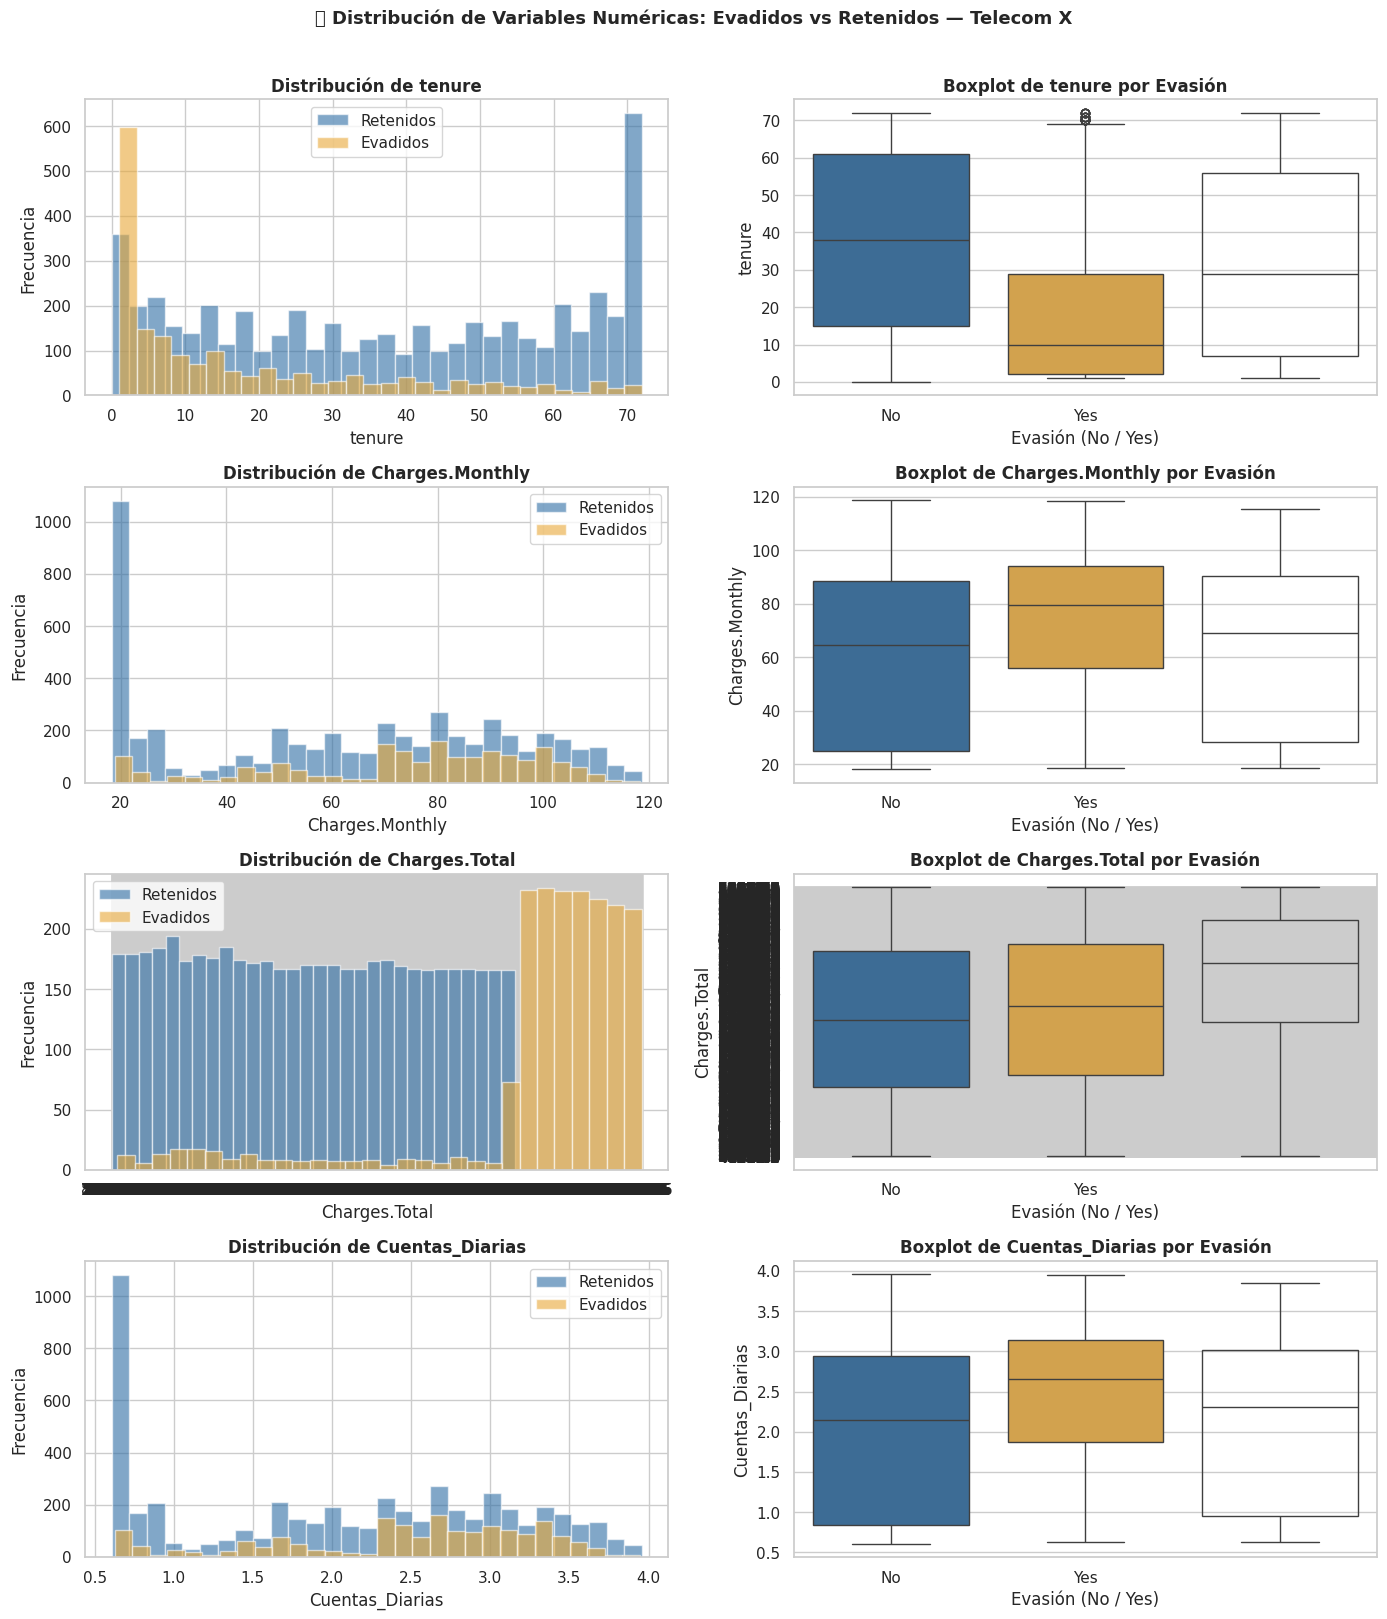

In [44]:
cols_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

fig, axes = plt.subplots(len(cols_numericas), 2, figsize=(14, 16))

for i, col in enumerate(cols_numericas):

    # Histograma
    for churn_val, color, label in [('No', '#2E6DA4', 'Retenidos'), ('Yes', '#E8A838', 'Evadidos')]:
        axes[i, 0].hist(
            df_flat[df_flat['Churn'] == churn_val][col].dropna(),
            bins=30, alpha=0.6, color=color, label=label, edgecolor='white'
        )
    axes[i, 0].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()

    # Boxplot
    df_box = df_flat[['Churn', col]].dropna()
    sns.boxplot(
        data=df_box, x='Churn', y=col,
        palette={'No': '#2E6DA4', 'Yes': '#E8A838'},
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Boxplot de {col} por Evasión', fontweight='bold')
    axes[i, 1].set_xlabel('Evasión (No / Yes)')
    axes[i, 1].set_ylabel(col)

plt.suptitle('📊 Distribución de Variables Numéricas: Evadidos vs Retenidos — Telecom X',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#📄Informe final